In [1]:
# FIXED DEPRICATED from IPython.core.display import display, HTML
from IPython.display import display, HTML

display(HTML("<style>.container { width:100% !important; }</style>"))
%matplotlib notebook
from argparse import ArgumentParser
import yaml
import os
import math
import torch
from torch.utils.data import DataLoader

import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP
# from torch import vmap

# FIXED DEPRICATED from functorch import vmap, grad
from torch.func import vmap, grad

from models import FNN2d, FNN3d
from train_utils import Adam
# from train_utils.datasets import BurgersLoader
# from train_utils.train_2d import train_2d_burger
# from train_utils.eval_2d import eval_burgers

from solver.WaveEq import WaveEq1D, WaveEq2D
import scipy.io
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import traceback

from tqdm import tqdm
from train_utils.utils import save_checkpoint, get_grid3d, convert_ic, torch2dgrid, load_checkpoint, load_config
from train_utils.losses import LpLoss
from train_utils.datasets import DataLoader2D

from solver.my_random_fields import GRF_Mattern


from importlib import reload
import imageio

try:
    import wandb
except ImportError:
    wandb = None


# Define Loss for Fourier Derivatives

In [2]:
def FDM_Wave2D(u, D=1, c=1.0):
    batchsize = u.size(0)
    nx = u.size(1)
    ny = u.size(2)
    nt = u.size(3)
    u = u.reshape(batchsize, nx, ny, nt)
    # Always allocate helpers on the same device as `u`
    dev = u.device

    dt = D / (nt-1)
    dx = D / (nx)

    u_h = torch.fft.fftn(u, dim=[1, 2])
    # Wavenumbers in y-direction
    k_max = nx//2
    N = nx
    k_x = torch.cat((torch.arange(start=0, end=k_max, step=1, device=dev),
                     torch.arange(start=-k_max, end=0, step=1, device=dev)), 0).reshape(N, 1).repeat(1, N).reshape(1,N,N,1)
    k_y = torch.cat((torch.arange(start=0, end=k_max, step=1, device=dev),
                     torch.arange(start=-k_max, end=0, step=1, device=dev)), 0).reshape(1, N).repeat(N, 1).reshape(1,N,N,1)
    ux_h = 2j *np.pi*k_x*u_h
    uxx_h = 2j *np.pi*k_x*ux_h
    uy_h = 2j *np.pi*k_y*u_h
    uyy_h = 2j *np.pi*k_y*uy_h
#     ux = torch.fft.irfft(ux_h[:, :, :k_max+1], dim=[1, 2])
    uxx = torch.fft.irfftn(uxx_h[:, :, :k_max+1], dim=[1, 2])
#     uy = torch.fft.irfft(uy_h[:, :, :k_max+1], dim=[1, 2])
    uyy = torch.fft.irfftn(uyy_h[:, :, :k_max+1], dim=[1, 2])

#     ut = (u[:, 2:, :] - u[:, :-2, :]) / (2 * dt)
    utt = (u[..., 2:] - 2.0*u[..., 1:-1] + u[..., :-2]) / (dt**2)
    Du = utt - c**2 * (uxx + uyy)[..., 1:-1]
    return Du


def PINO_loss_wave2D(u, u0, c=1.0):
    batchsize = u.size(0)
    nx = u.size(1)
    ny = u.size(2)
    nt = u.size(3)
    u = u.reshape(batchsize, nx, ny, nt)

    lploss = LpLoss(size_average=True)
    u_ic = u[..., 0]
    loss_ic = lploss(u_ic, u0)
#     index_t = torch.zeros(nx,).long()
#     index_x = torch.tensor(range(nx)).long()
#     boundary_u = u[:, index_t, index_x]
#     loss_u = F.mse_loss(boundary_u, u0)

#     Du = FDM_Wave(u, c=c)[:, :, :, :]
    Du = FDM_Wave2D(u, c=c)
    f = torch.zeros(Du.shape, device=u.device)
    loss_f = F.mse_loss(Du, f)

    # loss_bc0 = F.mse_loss(u[:, :, 0], u[:, :, -1])
    # loss_bc1 = F.mse_loss((u[:, :, 1] - u[:, :, -1]) /
    #                       (2/(nx)), (u[:, :, 0] - u[:, :, -2])/(2/(nx)))
    return loss_ic, loss_f

# Define Training Fuction

In [3]:
def train_wave2d(model,
                 dataset,
                 train_loader,
                 optimizer, scheduler,
                 config,
#                  c=1.0,
                 rank=0, log=False,
                 project='PINO-2d-default',
                 group='default',
                 tags=['default'],
                 use_tqdm=True):
    if rank == 0 and wandb and log:
        run = wandb.init(project=project,
                         entity='shawngr2',
                         group=group,
                         config=config,
                         tags=tags, reinit=True,
                         settings=wandb.Settings(start_method="fork"))

    data_weight = config['train']['xy_loss']
    f_weight = config['train']['f_loss']
    ic_weight = config['train']['ic_loss']
    ckpt_freq = config['train']['ckpt_freq']
    c = config['data']['c']
    model.train()
    myloss = LpLoss(size_average=True)
    S, T = dataset.S, dataset.T
    pbar = range(config['train']['epochs'])
    if use_tqdm:
        pbar = tqdm(pbar, dynamic_ncols=True, smoothing=0.1)

    for e in pbar:
        model.train()
        train_pino = 0.0
        train_ic = 0.0
        data_l2 = 0.0
        train_loss = 0.0
        

        for x, y in train_loader:
            x, y = x.to(rank), y.to(rank)
            out = model(x).reshape(y.shape)
            data_loss = myloss(out, y)
            loss_ic, loss_f = PINO_loss_wave2D(out, x[..., 0, -1], c=c)
            total_loss = loss_ic * ic_weight + loss_f * f_weight + data_loss * data_weight

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            data_l2 += data_loss.item()
            train_pino += loss_f.item()
            train_ic += loss_ic.item()
            train_loss += total_loss.item()
        scheduler.step()
        data_l2 /= len(train_loader)
        train_pino /= len(train_loader)
        train_ic /= len(train_loader)
        train_loss /= len(train_loader)
        if use_tqdm:
            pbar.set_description(
                (
                    f'Epoch {e}, train loss: {train_loss:.5f} '
                    f'train f error: {train_pino:.5f}; '
                    f'data l2 error: {data_l2:.5f}; '
                    f'train ic error: {train_ic:.5f}'
                )
            )
        if wandb and log:
            wandb.log(
                {
                    'Train f error': train_pino,
                    'Train L2 error': data_l2,
                    'Train ic error': loss_ic,
                    'Train loss': train_loss,
                }
            )

        if e % ckpt_freq == 0:
            save_checkpoint(config['train']['save_dir'],
                            config['train']['save_name'].replace('.pt', f'_{e}.pt'),
                            model, optimizer)
    save_checkpoint(config['train']['save_dir'],
                    config['train']['save_name'],
                    model, optimizer)
    print('Done!')

# Define Eval Function

In [4]:
def eval_wave2D(model,
                dataloader,
                config,
                device,
#                 c=1.0,
                use_tqdm=True):
    c = config['data']['c']
    model.eval()
    myloss = LpLoss(size_average=True)
    if use_tqdm:
        pbar = tqdm(dataloader, dynamic_ncols=True, smoothing=0.05)
    else:
        pbar = dataloader

    test_err = []
    f_err = []
    with torch.no_grad():
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            out = model(x).reshape(y.shape)
            data_loss = myloss(out, y)

            loss_ic, f_loss = PINO_loss_wave2D(out, x[..., 0, -1], c=c)
            test_err.append(data_loss.item())
            f_err.append(f_loss.item())

    mean_f_err = np.mean(f_err)
    std_f_err = np.std(f_err, ddof=1) / np.sqrt(len(f_err))

    mean_err = np.mean(test_err)
    std_err = np.std(test_err, ddof=1) / np.sqrt(len(test_err))

    print(f'==Averaged relative L2 error mean: {mean_err}, std error: {std_err}==\n'
          f'==Averaged equation error mean: {mean_f_err}, std error: {std_f_err}==')



# Define Parameters

In [5]:
dim = 2
N = 128
Nx = 128
Ny = 128
l = 0.1
L = 1.0
sigma = 1.0
Nu = None
Nsamples = 50
dt = 1.0e-4
save_int = int(1e-2/dt)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [6]:
device

device(type='cuda', index=0)

# Generate Random Fields

In [7]:
grf = GRF_Mattern(dim, N, length=L, nu=Nu, l=l, sigma=sigma, boundary="periodic", device=device)
U0 = grf.sample(Nsamples)

In [8]:
u0 = U0[0].cpu()
u0

tensor([[-0.1266, -0.1740, -0.2194,  ...,  0.0123, -0.0318, -0.0786],
        [-0.1404, -0.1885, -0.2344,  ...,  0.0008, -0.0441, -0.0917],
        [-0.1550, -0.2032, -0.2490,  ..., -0.0130, -0.0582, -0.1061],
        ...,
        [-0.0926, -0.1349, -0.1755,  ...,  0.0304, -0.0086, -0.0501],
        [-0.1023, -0.1468, -0.1895,  ...,  0.0273, -0.0138, -0.0575],
        [-0.1138, -0.1600, -0.2043,  ...,  0.0212, -0.0216, -0.0671]])

In [9]:
u0.shape

torch.Size([128, 128])

# Plot Random Fields

In [10]:
key = 0
x = torch.linspace(0, 1, Nx + 1)[:-1]
y = torch.linspace(0, 1, Nx + 1)[:-1]
X, Y = torch.meshgrid(x, y, indexing='ij')
u0 = U0[key].cpu().numpy()
u0

array([[-0.12658249, -0.17403445, -0.21937762, ...,  0.01230361,
        -0.03181181, -0.07863276],
       [-0.14040141, -0.18852614, -0.2343867 , ...,  0.00082741,
        -0.04406614, -0.09168597],
       [-0.15497713, -0.20320867, -0.24903   , ..., -0.01302158,
        -0.05818198, -0.10605748],
       ...,
       [-0.09260598, -0.1348641 , -0.17547263, ...,  0.03043728,
        -0.00859044, -0.05005477],
       [-0.10234657, -0.14683113, -0.18952122, ...,  0.02731999,
        -0.01381803, -0.05751837],
       [-0.11379063, -0.1600197 , -0.20429881, ...,  0.02120501,
        -0.02164572, -0.06714787]], dtype=float32)

In [11]:
fig = plt.figure()
# fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
# surf = ax.plot_surface(X, Y, u0, cmap='jet', linewidth=0, antialiased=True, vmin=-2, vmax=2)
c = plt.pcolormesh(X, Y, u0, cmap='jet', shading='gouraud')

# fig.colorbar(surf, shrink=0.5, aspect=5)
fig.colorbar(c)

plt.title('GRF 2D')
plt.axis('square')
plt.show()

<IPython.core.display.Javascript object>

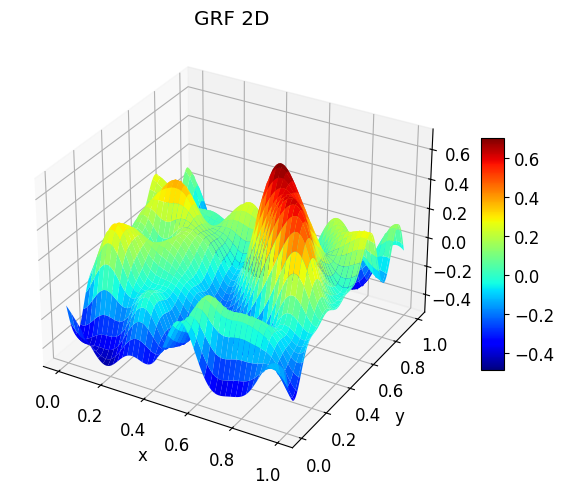

In [12]:
%matplotlib inline
font_size=12
plt.rcParams.update({'font.size': font_size})
fig, ax = plt.subplots(figsize=(6,5), subplot_kw={"projection": "3d"})
surf = ax.plot_surface(X, Y, u0, cmap='jet', linewidth=0, antialiased=True,)
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.tight_layout()
plt.title('GRF 2D')
plt.xlabel('x')
plt.ylabel('y')
# plt.show()
plt.savefig('grf_2D.png', bbox_inches='tight')

# GRF stands for Gaussian Random Field. It is our way of setting the initial condition (see paper)


# Evolve the Wave Equation

In [13]:
wave_eq = WaveEq2D(Nx=Nx, Ny=Ny, dt=dt, device=device)
U = vmap(wave_eq.wave_driver, in_dims=(0, None))(U0, save_int)

In [14]:
a = U0.cpu().float()
u = U.cpu().float()
display(u.shape,a.shape)

torch.Size([50, 101, 128, 128])

torch.Size([50, 128, 128])

# Plot Data

NameError: name 'make_axes_locatable' is not defined

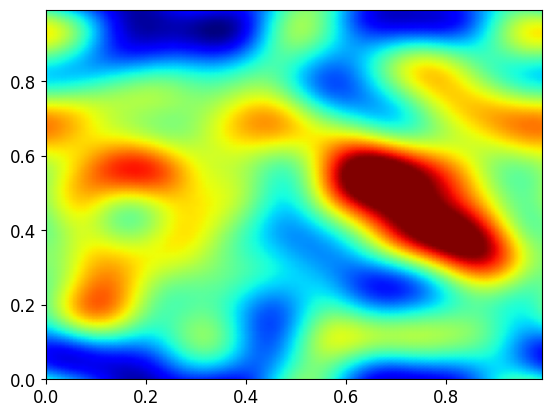

In [16]:
# %matplotlib notebook
fig = plt.figure()
ax = fig.add_subplot(111)
plt.ion()

fig.show()
fig.canvas.draw()


x = torch.linspace(0, 1, Nx + 1)[:-1]
y = torch.linspace(0, 1, Nx + 1)[:-1]
X, Y = torch.meshgrid(x, y, indexing='ij')
# u = U[key].cpu().numpy()
# u0

pcm = ax.pcolormesh(X, Y, u[key, 0], vmin=-0.5, vmax=0.5, cmap='jet', shading='gouraud')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)

plt.colorbar(pcm, ax=ax)
# ax.

plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(f'Wave Equation')
plt.axis('square')
plt.tight_layout()

movie_dir = "Wave2D_movie"
movie_filename = "Wave2D_movie"
movie_files = []
os.makedirs(movie_dir, exist_ok=True)
for i in range(len(u)):
    ax.clear()
    pcm = ax.pcolormesh(X, Y, u[key, i], vmin=-0.5, vmax=0.5, cmap='jet', shading='gouraud')
    plt.colorbar(pcm, ax=ax)
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.title(f'Wave Equation')
    plt.axis('square')
    plt.tight_layout()
    fig.canvas.draw()
    movie_path = os.path.join(movie_dir,f'{movie_filename}-{i:03}.png')
    movie_files.append(movie_path)
    plt.savefig(movie_path)

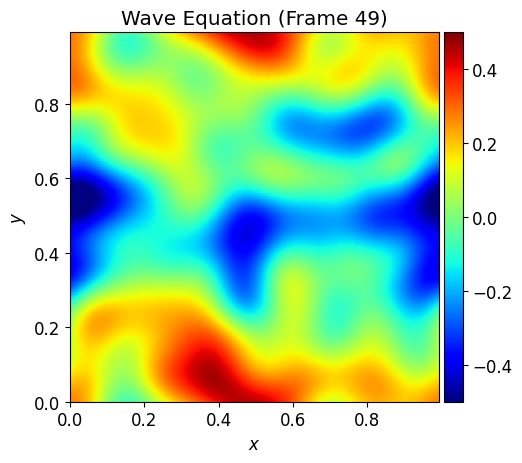

In [17]:
# Fixed Cell to above to remove display errors

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os

fig, ax = plt.subplots()
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)

# Initialize the plot with the first frame
# We store pcm in a variable so we can update it
pcm = ax.pcolormesh(X, Y, u[key, 0], vmin=-0.5, vmax=0.5, cmap='jet', shading='gouraud')
fig.colorbar(pcm, cax=cax) # Use the dedicated cax we created

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Wave Equation')
ax.set_aspect('equal')
plt.tight_layout()

movie_dir = "Wave2D_movie"
os.makedirs(movie_dir, exist_ok=True)

for i in range(len(u)):
    # INSTEAD OF ax.clear(), just update the array data
    # This is much faster and prevents layout shifting
    pcm.set_array(u[key, i].flatten()) 
    
    # Update title if you want to show frame number
    ax.set_title(f'Wave Equation (Frame {i})')
    
    movie_path = os.path.join(movie_dir, f'Wave2D_movie-{i:03}.png')
    plt.savefig(movie_path)
    
    # Optional: for interactive viewing
    # fig.canvas.draw()
    # plt.pause(0.01)

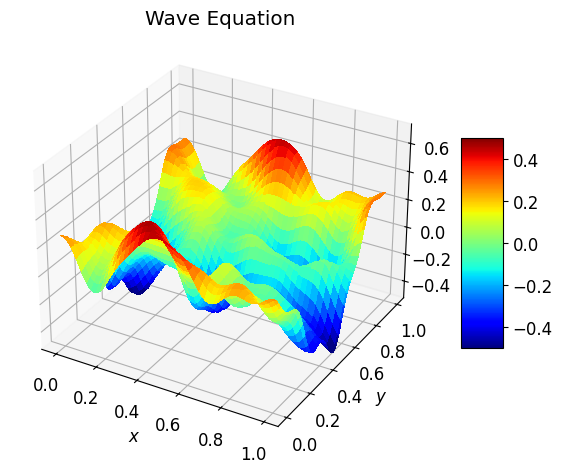

In [18]:
# %matplotlib notebook
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

plt.ion()

fig.show()
fig.canvas.draw()


x = torch.linspace(0, 1, Nx + 1)[:-1]
y = torch.linspace(0, 1, Nx + 1)[:-1]
X, Y = torch.meshgrid(x, y, indexing='ij')
# u = U[key].cpu().numpy()
# u0
surf = ax.plot_surface(X, Y, u[key, 0].cpu().numpy(), cmap='jet', vmin=-0.5, vmax=0.5, linewidth=0, antialiased=False)

# pcm = ax.pcolormesh(X, Y, u[0], vmin=-0.5, vmax=0.5, cmap='jet', shading='gouraud')
# divider = make_axes_locatable(ax)
# cax = divider.append_axes("right", size="5%", pad=0.05)

# plt.colorbar(surf, ax=ax)
fig.colorbar(surf, shrink=0.5, aspect=5)

# ax.
# ax.set_zlim(-1, 1)
# display(ax.get_zlim())
zlim = ax.get_zlim()
ax.set_zlim(zlim)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(f'Wave Equation')
# plt.axis('square')
plt.tight_layout()

# movie_dir = "Wave2D_movie"
# movie_filename = "Wave2D_movie"
# movie_files = []
# os.makedirs(movie_dir, exist_ok=True)
for i in range(len(u)):
    ax.clear()
#     pcm = ax.pcolormesh(X, Y, u[i], vmin=-0.5, vmax=0.5, cmap='jet', shading='gouraud')
    surf = ax.plot_surface(X, Y, u[key, i].cpu().numpy(), cmap='jet', vmin=-0.5, vmax=0.5, linewidth=0, antialiased=False)
    ax.set_zlim(zlim)
#     plt.colorbar(pcm, ax=ax)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
#     ax.set_zlabel('$u$')
    plt.title(f'Wave Equation')
#     plt.axis('square')
    plt.tight_layout()
    fig.canvas.draw()
#     movie_path = os.path.join(movie_dir,f'{movie_filename}-{i:03}.png')
#     movie_files.append(movie_path)
#     plt.savefig(movie_path)



# Load Configuration File

In [19]:
config_file = 'configs/custom/wave2D-0000.yaml'
config = load_config(config_file)
display(config)

{'data': {'name': 'Wave2D-0000',
  'total_num': 50,
  'n_train': 45,
  'n_test': 5,
  'nx': 128,
  'nt': 100,
  'sub': 1,
  'sub_t': 1,
  'c': 1.0},
 'model': {'layers': [64, 64, 64, 64, 64],
  'modes1': [8, 8, 8, 8],
  'modes2': [8, 8, 8, 8],
  'modes3': [8, 8, 8, 8],
  'fc_dim': 128,
  'activation': 'gelu',
  'padding': 5},
 'train': {'batchsize': 1,
  'epochs': 100,
  'milestones': [25, 50, 75, 100],
  'base_lr': 0.001,
  'scheduler_gamma': 0.5,
  'ic_loss': 5.0,
  'f_loss': 1.0,
  'xy_loss': 5.0,
  'save_dir': 'Wave2D',
  'save_name': 'Wave2D-0000.pt',
  'ckpt': 'checkpoints/Wave2D/Wave2D-0000.pt',
  'ckpt_freq': 25},
 'log': {'project': 'PINO-Wave', 'group': 'Wave2D-0000'},
 'test': {'batchsize': 1, 'ckpt': 'checkpoints/WaveD/Wave2D-0000.pt'}}

# Define the DataLoaders

In [20]:
dataset = DataLoader2D(u, config['data']['nx'], config['data']['nt'], config['data']['sub'], config['data']['sub_t'])
train_loader = dataset.make_loader(config['data']['n_train'], config['train']['batchsize'], start=0, train=True)
test_loader = dataset.make_loader(config['data']['n_test'], config['test']['batchsize'], start=config['data']['n_train'], train=False)

In [21]:
x,y = next(iter(train_loader))

In [22]:
x_in = F.pad(x, (0, 0, 0, 5, 0, 0, 0, 0), "constant", 0)

In [23]:
x_in.shape

torch.Size([1, 128, 128, 106, 4])

# Define the Model

In [24]:
log = False
# config = config_train
model = FNN3d(modes1=config['model']['modes1'],
              modes2=config['model']['modes2'],
              modes3=config['model']['modes3'],
              fc_dim=config['model']['fc_dim'],
              layers=config['model']['layers'], 
              activation=config['model']['activation'],
              pad_z=config['model']['padding']
             ).to(device)

optimizer = Adam(model.parameters(), betas=(0.9, 0.999), lr=config['train']['base_lr'])
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer,
                                                 milestones=config['train']['milestones'],
                                                 gamma=config['train']['scheduler_gamma'])

# Load from checkpoint

In [25]:
load_checkpoint(model, ckpt_path=config['train']['ckpt'], optimizer=None)

Weights loaded from checkpoints/Wave2D/Wave2D-0000.pt


# Train the Model

In [24]:
train_wave2d(model,
             dataset,
             train_loader,
             optimizer,
             scheduler,
             config,
#              c=config['data']['c'],
             rank=0,
             log=log,
             project=config['log']['project'],
             group=config['log']['group'])

Epoch 0, train loss: 11.20916 train f error: 1.29028; data l2 error: 0.99706; train ic error: 0.98672:   1%|          | 1/100 [00:27<44:50, 27.18s/it]

Checkpoint is saved at checkpoints/Wave2D/Wave2D-0000_0.pt


Epoch 25, train loss: 0.28916 train f error: 0.07970; data l2 error: 0.02072; train ic error: 0.02117:  26%|██▌       | 26/100 [11:06<31:38, 25.66s/it]

Checkpoint is saved at checkpoints/Wave2D/Wave2D-0000_25.pt


Epoch 50, train loss: 0.16311 train f error: 0.02337; data l2 error: 0.01424; train ic error: 0.01371:  51%|█████     | 51/100 [21:46<20:57, 25.67s/it]

Checkpoint is saved at checkpoints/Wave2D/Wave2D-0000_50.pt


Epoch 75, train loss: 0.09845 train f error: 0.01241; data l2 error: 0.00938; train ic error: 0.00782:  76%|███████▌  | 76/100 [32:26<10:16, 25.67s/it]

Checkpoint is saved at checkpoints/Wave2D/Wave2D-0000_75.pt


Epoch 99, train loss: 0.08778 train f error: 0.01155; data l2 error: 0.00831; train ic error: 0.00694: 100%|██████████| 100/100 [42:39<00:00, 25.59s/it]


Checkpoint is saved at checkpoints/Wave2D/Wave2D-0000.pt
Done!


In [33]:
train_wave2d(model,
             dataset,
             train_loader,
             optimizer,
             scheduler,
             config,
             c=config['data']['c'],
             rank=0,
             log=log,
             project=config['log']['project'],
             group=config['log']['group'])

  0%|          | 0/150 [00:00<?, ?it/s]/jet/home/shawngr2/.local/lib/python3.8/site-packages/torch/autograd/__init__.py:173: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at  ../aten/src/ATen/native/Copy.cpp:237.)
  Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Epoch 0, train loss: 1.64529 train f error: 0.93369; data l2 error: 0.06710; train ic error: 0.06445:   1%|          | 1/150 [00:22<54:43, 22.04s/it]

Checkpoint is saved at checkpoints/Wave2D/Wave2D-0000_0.pt


Epoch 25, train loss: 0.18098 train f error: 0.01783; data l2 error: 0.01708; train ic error: 0.01461:  17%|█▋        | 26/150 [10:42<58:29, 28.30s/it]

Checkpoint is saved at checkpoints/Wave2D/Wave2D-0000_25.pt


Epoch 50, train loss: 0.09589 train f error: 0.00708; data l2 error: 0.01176; train ic error: 0.00771:  34%|███▍      | 51/150 [23:36<50:49, 30.81s/it]

...

Checkpoint is saved at checkpoints/Wave2D/Wave2D-0000_100.pt


Epoch 125, train loss: 0.02934 train f error: 0.00171; data l2 error: 0.00913; train ic error: 0.00185:  84%|████████▍ | 126/150 [1:01:59<12:01, 30.08s/it]

Checkpoint is saved at checkpoints/Wave2D/Wave2D-0000_125.pt


Epoch 149, train loss: 0.02965 train f error: 0.00165; data l2 error: 0.00910; train ic error: 0.00189: 100%|██████████| 150/150 [1:13:38<00:00, 29.45s/it]


Checkpoint is saved at checkpoints/Wave2D/Wave2D-0000.pt
Done!


### Old Model for Comparison

In [36]:
train_wave2d(model,
             dataset,
             train_loader,
             optimizer,
             scheduler,
             config,
             c=config['data']['c'],
             rank=0,
             log=log,
             project=config['log']['project'],
             group=config['log']['group'])

  0%|          | 0/500 [00:00<?, ?it/s]/jet/home/shawngr2/.local/lib/python3.8/site-packages/torch/autograd/__init__.py:173: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at  ../aten/src/ATen/native/Copy.cpp:237.)
  Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Epoch 0, train loss: 12.16554 train f error: 1.29981; data l2 error: 1.00512:   0%|          | 1/500 [00:21<2:58:32, 21.47s/it]

Checkpoint is saved at checkpoints/Wave2D/Wave2D-0000_0.pt


Epoch 100, train loss: 0.71877 train f error: 0.04601; data l2 error: 0.06258:  20%|██        | 101/500 [33:36<2:13:45, 20.11s/it]

Checkpoint is saved at checkpoints/Wave2D/Wave2D-0000_100.pt


Epoch 200, train loss: 0.54671 train f error: 0.01872; data l2 error: 0.05360:  40%|████      | 201/500 [1:06:49<1:39:54, 20.05s/it]

...

Checkpoint is saved at checkpoints/Wave2D/Wave2D-0000_300.pt


Epoch 400, train loss: 0.50422 train f error: 0.00724; data l2 error: 0.05272:  80%|████████  | 401/500 [2:13:21<32:58, 19.99s/it]  

Checkpoint is saved at checkpoints/Wave2D/Wave2D-0000_400.pt


Epoch 499, train loss: 0.50743 train f error: 0.00920; data l2 error: 0.05292: 100%|██████████| 500/500 [2:46:11<00:00, 19.94s/it]


Checkpoint is saved at checkpoints/Wave2D/Wave2D-0000.pt
Done!


# Evaluate Model

In [26]:
eval_wave2D(model,
            test_loader,
            config,
            device,
#             c=config['data']['c'],
            use_tqdm=True)

100%|██████████| 5/5 [00:01<00:00,  4.66it/s]

==Averaged relative L2 error mean: 0.007837904524058104, std error: 5.880734148680674e-05==
==Averaged equation error mean: 0.02109678164124489, std error: 0.003955138260969932==


In [35]:
eval_wave2D(model,
            test_loader,
            config,
            device,
            c=config['data']['c'],
            use_tqdm=True)

TypeError: eval_wave2D() got an unexpected keyword argument 'c'

# Resolution Invariance Test


For the 2D case, the dataset u is generated at nx0 = 128, so we cannot currently evaluate at finer than 128 resolution without generating a new higher resolution dataset. We can only perform coarsening: 128, 64, 32, 16, 8.

So, we first will pick a larger reference grid, and generate u_ref by running the wave solver at that resolution, downsample for ground truth comparison, so that we can test the performance at super resolution.

In [27]:
# (Disabled) Old resolution invariance block from 1D template.
# Use the fixed block below that derives valid sub_x values from config and model modes.


In [27]:
# =============================================================================
# Super-resolution Resolution Invariance Test (2D)
# -----------------------------------------------------------------------------
# Goal: evaluate the same trained checkpoint on resolutions ABOVE training.
#
# We do this by generating a high-resolution reference dataset (u_ref) at
# nx_ref, then evaluating the model at Nx_eval in Nx_list by downsampling
# u_ref via DataLoader2D(sub=sub_x).
#
# Notes:
# - SpectralConv3d requires Nx_eval, Ny_eval >= max(modes1, modes2).
# - DataLoader2D expects data shaped (nsamples, T, X, Y) where data[:,0] is the
#   initial condition (used as the 'a' channel).
# - If you re-run after editing train_utils/datasets.py, we reload the module.
# =============================================================================

import importlib
import train_utils.datasets as datasets
importlib.reload(datasets)
from train_utils.datasets import DataLoader2D

import matplotlib.pyplot as plt

# Pick the CUDA device with the most free memory (helps avoid OOM on cuda:0).
import gc
if torch.cuda.is_available():
    free_by_dev = []
    for i in range(torch.cuda.device_count()):
        free_i, total_i = torch.cuda.mem_get_info(i)
        free_by_dev.append((int(free_i), int(total_i), i))
    free_by_dev.sort(reverse=True)
    best_free, best_total, best_i = free_by_dev[0]
    eval_device = torch.device(f'cuda:{best_i}')
    print(f'Using eval_device={eval_device} (free={best_free/1e9:.2f} GB / total={best_total/1e9:.2f} GB)')
else:
    eval_device = torch.device('cpu')

# Move model once to the selected eval device.
model = model.to(eval_device)

# --- config / knobs ---
n_train = int(config['data']['n_train'])
n_test  = int(config['data']['n_test'])
test_bs = int(config['test']['batchsize'])

nx_train = int(config['data']['nx'])
nt0 = int(config['data']['nt'])
sub_t = int(config['data']['sub_t'])

# pick a reference resolution (must be >= nx_train).
nx_ref = 512  # set to 256 if 512 is too slow

# list eval resolutions explicitly (readable), then filter
Nx_list = [16, 32, 64, 128, 256, 512]

min_nx = max(max(config['model']['modes1']), max(config['model']['modes2']))
Nx_list = [Nx for Nx in Nx_list if (Nx >= min_nx and Nx <= nx_ref and nx_ref % Nx == 0)]
if len(Nx_list) == 0:
    raise ValueError(f'No valid Nx in Nx_list after filtering; min_nx={min_nx}, nx_ref={nx_ref}')

Nt_eval = nt0 // sub_t + 1

# --- build / cache high-res reference data ---
# This uses the same GRF hyperparams and wave solver used earlier in the notebook
# (dim, L, Nu, l, sigma, dt, save_int must already exist).
if 'u_ref' not in globals() or (hasattr(u_ref, 'shape') and u_ref.shape[-1] != nx_ref):
    print(f'Generating u_ref at nx_ref={nx_ref} for n_test={n_test} ...')
    grf_ref = GRF_Mattern(dim, nx_ref, length=L, nu=Nu, l=l, sigma=sigma, boundary='periodic', device=eval_device)
    U0_ref = grf_ref.sample(n_test)
    wave_eq_ref = WaveEq2D(Nx=nx_ref, Ny=nx_ref, dt=dt, device=eval_device)
    U_ref = vmap(wave_eq_ref.wave_driver, in_dims=(0, None))(U0_ref, save_int)
    u_ref = U_ref.cpu().float()
    print('u_ref shape:', tuple(u_ref.shape))
else:
    print('Reusing cached u_ref shape:', tuple(u_ref.shape))

# --- evaluate across resolutions ---
results = []
model.eval()
myloss = LpLoss(size_average=True)

for Nx_eval in Nx_list:
    sub_x = nx_ref // Nx_eval
    ds = DataLoader2D(u_ref, nx=nx_ref, nt=nt0, sub=sub_x, sub_t=sub_t)
    # u_ref only contains the evaluation set, so start=0
    test_loader_res = ds.make_loader(n_test, test_bs, start=0, train=False)

    print(f'\n--- Evaluating at Nx={Nx_eval}, Nt={Nt_eval} (sub_x={sub_x}, nx_ref={nx_ref}, nx_train={nx_train}) ---')
    if eval_device.type == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()

    test_err, f_err = [], []
    with torch.no_grad():
        for x, y in test_loader_res:
            x, y = x.to(eval_device), y.to(eval_device)
            out = model(x).reshape(y.shape)
            test_err.append(myloss(out, y).item())
            _, f_loss = PINO_loss_wave2D(out, x[..., 0, -1], c=config['data']['c'])
            f_err.append(f_loss.item())

    mean_err   = float(np.mean(test_err))
    mean_f_err = float(np.mean(f_err))
    print(f'  rel L2 error (data)  : {mean_err:.5f}')
    print(f'  equation residual    : {mean_f_err:.5e}')
    results.append((Nx_eval, mean_err, mean_f_err))

results = np.array(results)
print('\nresults shape:', results.shape, '  columns: [Nx, rel_L2, eq_residual]')

# quick plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.plot(results[:, 0], results[:, 1], 'o-', color='tab:blue')
ax.axvline(nx_train, color='gray', ls='--', label=f'Train resolution (Nx={nx_train})')
ax.set_xscale('log', base=2)
ax.set_xlabel('Spatial resolution Nx (eval)')
ax.set_ylabel('Relative L2 error')
ax.set_title('Prediction error vs resolution')
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1]
ax.plot(results[:, 0], results[:, 2], 'o-', color='tab:red')
ax.axvline(nx_train, color='gray', ls='--', label=f'Train resolution (Nx={nx_train})')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel('Spatial resolution Nx (eval)')
ax.set_ylabel('Equation residual (MSE)')
ax.set_title('Wave residual vs resolution')
ax.grid(True, which='both', alpha=0.3)
ax.legend()

plt.tight_layout()


Using eval_device=cuda:1 (free=11.38 GB / total=11.55 GB)
Generating u_ref at nx_ref=512 for n_test=5 ...
u_ref shape: (5, 101, 512, 512)

--- Evaluating at Nx=16, Nt=101 (sub_x=32, nx_ref=512, nx_train=128) ---
  rel L2 error (data)  : 0.00859
  equation residual    : 3.27767e-02

--- Evaluating at Nx=32, Nt=101 (sub_x=16, nx_ref=512, nx_train=128) ---
  rel L2 error (data)  : 0.00834
  equation residual    : 1.79575e-02

--- Evaluating at Nx=64, Nt=101 (sub_x=8, nx_ref=512, nx_train=128) ---
  rel L2 error (data)  : 0.00837
  equation residual    : 1.51522e-02

--- Evaluating at Nx=128, Nt=101 (sub_x=4, nx_ref=512, nx_train=128) ---
  rel L2 error (data)  : 0.00842
  equation residual    : 1.51322e-02

--- Evaluating at Nx=256, Nt=101 (sub_x=2, nx_ref=512, nx_train=128) ---


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.69 GiB. GPU 1 has a total capacity of 10.75 GiB of which 1005.62 MiB is free. Including non-PyTorch memory, this process has 9.77 GiB memory in use. Of the allocated memory 9.07 GiB is allocated by PyTorch, and 516.45 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

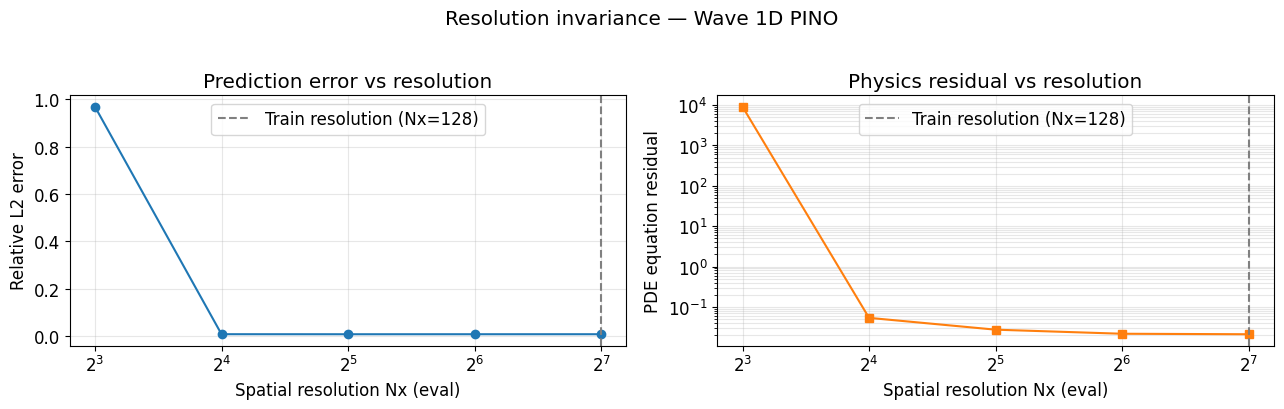

In [26]:
%matplotlib inline
import matplotlib.pyplot as plt

train_nx = config['data']['nx'] // config['data']['sub']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(results[:, 0], results[:, 1], 'o-', color='tab:blue')
ax.axvline(train_nx, color='gray', ls='--', label=f'Train resolution (Nx={train_nx})')
ax.set_xscale('log', base=2)
ax.set_xlabel('Spatial resolution Nx (eval)')
ax.set_ylabel('Relative L2 error')
ax.set_title('Prediction error vs resolution')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(results[:, 0], results[:, 2], 's-', color='tab:orange')
ax.axvline(train_nx, color='gray', ls='--', label=f'Train resolution (Nx={train_nx})')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel('Spatial resolution Nx (eval)')
ax.set_ylabel('PDE equation residual')
ax.set_title('Physics residual vs resolution')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

plt.suptitle('Resolution invariance — Wave 1D PINO', y=1.02)
plt.tight_layout()
plt.show()

# Generate Test Predictions

In [27]:
Nx = config['data']['nx']
Ny = config['data']['nx']
Nt = config['data']['nt'] + 1
Ntest = config['data']['n_test']
model.eval()
test_x = np.zeros((Ntest,Nx,Ny,Nt,4))
preds_y = np.zeros((Ntest,Nx,Ny,Nt))
test_y = np.zeros((Ntest,Nx,Ny,Nt))
with torch.no_grad():
    for i, data in enumerate(test_loader):
        data_x, data_y = data
        data_x, data_y = data_x.to(device), data_y.to(device)
        pred_y = model(data_x).reshape(data_y.shape)
        test_x[i] = data_x.cpu().numpy()
        test_y[i] = data_y.cpu().numpy()
        preds_y[i] = pred_y.cpu().numpy()
#     data_loss = myloss(out, y)

In [28]:
X

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0078, 0.0078, 0.0078,  ..., 0.0078, 0.0078, 0.0078],
        [0.0156, 0.0156, 0.0156,  ..., 0.0156, 0.0156, 0.0156],
        ...,
        [0.9766, 0.9766, 0.9766,  ..., 0.9766, 0.9766, 0.9766],
        [0.9844, 0.9844, 0.9844,  ..., 0.9844, 0.9844, 0.9844],
        [0.9922, 0.9922, 0.9922,  ..., 0.9922, 0.9922, 0.9922]])

In [29]:
Y

tensor([[0.0000, 0.0078, 0.0156,  ..., 0.9766, 0.9844, 0.9922],
        [0.0000, 0.0078, 0.0156,  ..., 0.9766, 0.9844, 0.9922],
        [0.0000, 0.0078, 0.0156,  ..., 0.9766, 0.9844, 0.9922],
        ...,
        [0.0000, 0.0078, 0.0156,  ..., 0.9766, 0.9844, 0.9922],
        [0.0000, 0.0078, 0.0156,  ..., 0.9766, 0.9844, 0.9922],
        [0.0000, 0.0078, 0.0156,  ..., 0.9766, 0.9844, 0.9922]])

In [38]:
T

NameError: name 'T' is not defined

In [39]:
key_t

NameError: name 'key_t' is not defined

# Plot Results

In [30]:
key = 0
key_t = (Nt - 1) 
pred = preds_y[key]
true = test_y[key]


a = test_x[key]
# Nt, Nx, _ = a.shape
u0 = a[..., 0, -1]
pred_t = pred[..., key_t]
true_t = true[..., key_t]
# T = a[:,:,2]
# X = a[:,:,1]
# x = X[0]
x = torch.linspace(0, 1, Nx + 1)[:-1]
y = torch.linspace(0, 1, Nx + 1)[:-1]
X, Y = torch.meshgrid(x, y, indexing='ij')
t = a[0, 0, key_t, 2]
grid_x, grid_y, grid_t = get_grid3d(Nx, Nt)
# X = X.reshape(Nx, Nx)

(np.float64(0.0),
 np.float64(0.9921875),
 np.float64(0.0),
 np.float64(0.9921875))

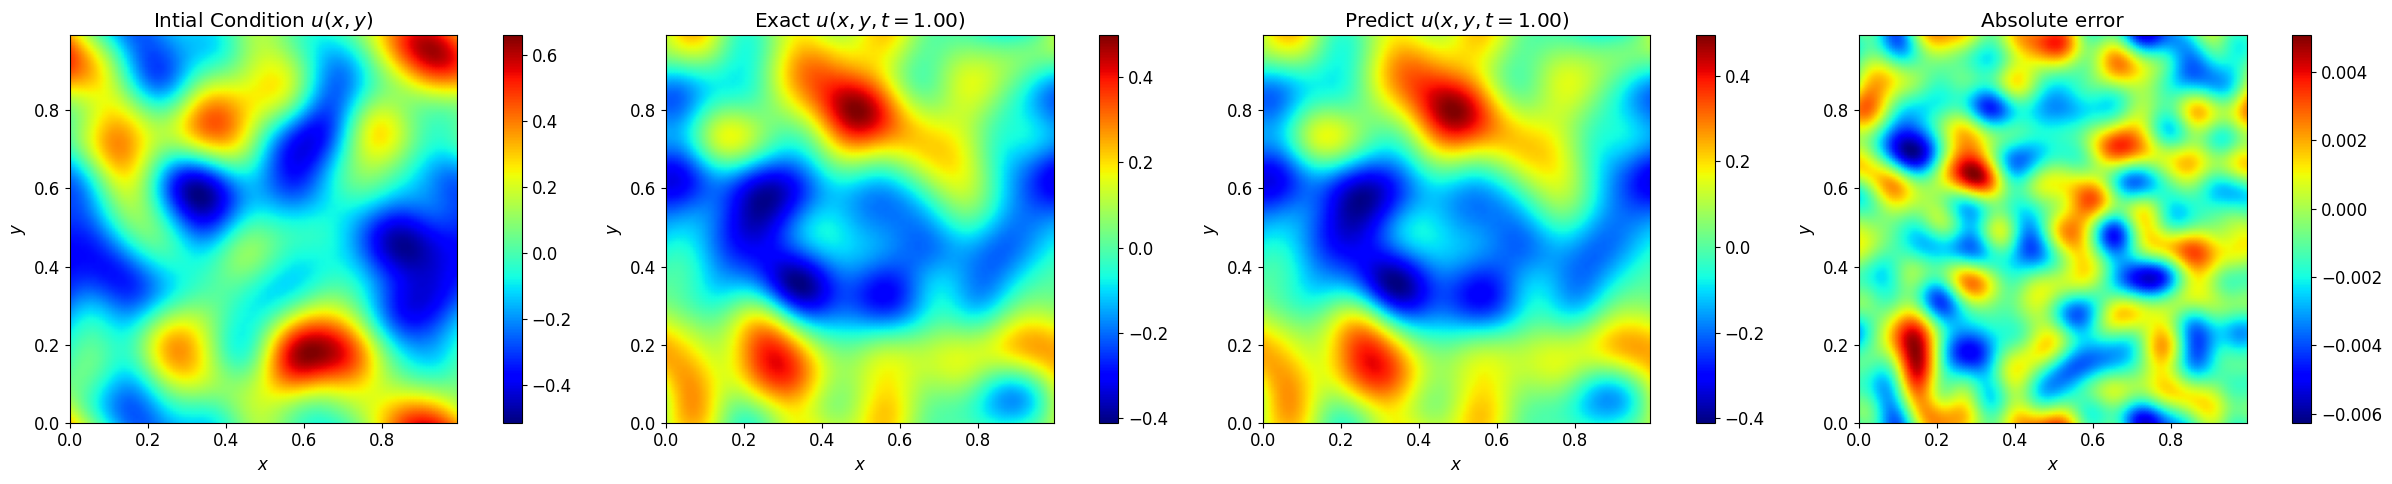

In [31]:
fig = plt.figure(figsize=(24,5))
plt.subplot(1,4,1)

plt.pcolormesh(X, Y, u0, cmap='jet', shading='gouraud')
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Intial Condition $u(x,y)$')
plt.tight_layout()
plt.axis('square')

plt.subplot(1,4,2)
# plt.pcolor(XX,TT, S_test, cmap='jet')
plt.pcolormesh(X, Y, true_t, cmap='jet', shading='gouraud')
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(f'Exact $u(x,y,t={t:.2f})$')
plt.tight_layout()
plt.axis('square')

plt.subplot(1,4,3)
# plt.pcolor(XX,TT, S_pred, cmap='jet')
plt.pcolormesh(X, Y, pred_t, cmap='jet', shading='gouraud')
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(f'Predict $u(x,y,t={t:.2f})$')
plt.axis('square')

plt.tight_layout()

plt.subplot(1,4,4)
# plt.pcolor(XX,TT, S_pred - S_test, cmap='jet')
plt.pcolormesh(X, Y, pred_t - true_t, cmap='jet', shading='gouraud')
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Absolute error')
plt.tight_layout()
plt.axis('square')

# plt.show()

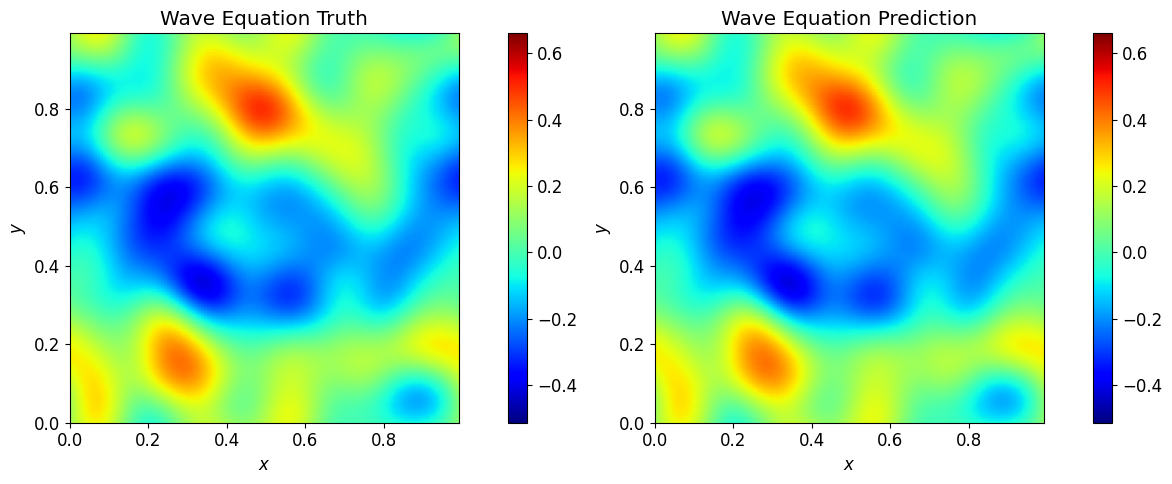

In [32]:
# %matplotlib notebook
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

plt.ion()

fig.show()
fig.canvas.draw()


x = torch.linspace(0, 1, Nx + 1)[:-1]
y = torch.linspace(0, 1, Nx + 1)[:-1]
X, Y = torch.meshgrid(x, y, indexing='ij')
# u = U[key].cpu().numpy()
# u0
# pcm1 = ax1.plot_pcmace(X, Y, true[..., 0], cmap='jet', label='true', alpha=1.0, rstride=1, cstride=1, linewidth=0.0, antialiased=False)
pcm1 = ax1.pcolormesh(X, Y, true[..., 0], cmap='jet', label='true', shading='gouraud')

# plt.colorbar()
# pcm2 = ax2.plot_pcmace(X, Y, pred[..., 0], cmap='jet', label='pred', alpha=1.0, rstride=1, cstride=1, linewidth=0.0, antialiased=False)
pcm2 = ax2.pcolormesh(X, Y, pred[..., 0], cmap='jet', label='pred', shading='gouraud')

# pcm = ax.pcolormesh(X, Y, u[0], vmin=-0.5, vmax=0.5, cmap='jet', shading='gouraud')
# divider = make_axes_locatable(ax2)
# cax = divider.append_axes("right", size="5%", pad=0.05)


# fig.colorbar(pcm, shrink=0.5, aspect=5)

# ax.
# ax.set_clim(-1, 1)
# display(ax.get_clim())
clim = pcm1.get_clim()
pcm1.set_clim(clim)
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')
pcm2.set_clim(clim)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$y$')
ax1.set_title(f'Wave Equation Truth')
ax2.set_title(f'Wave Equation Prediction')

# plt.axis('square')

plt.colorbar(pcm1, ax=ax1)
plt.colorbar(pcm2, ax=ax2)
ax1.axis('square')
ax2.axis('square')
plt.tight_layout()
# ax2.tight_layout()

# movie_dir = "Wave2D_movie"
# movie_filename = "Wave2D_movie"
# movie_files = []
# os.makedirs(movie_dir, exist_ok=True)
for i in range(pred.shape[-1]):
    ax1.clear()
    ax2.clear()
    pcm1 = ax1.pcolormesh(X, Y, true[..., i], cmap='jet', label='true', shading='gouraud')

    pcm2 = ax2.pcolormesh(X, Y, pred[..., i], cmap='jet', label='pred', shading='gouraud')
#     plt.axis('square')

    pcm1.set_clim(clim)
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$y$')
    pcm2.set_clim(clim)
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$y$')
    ax1.set_title(f'Wave Equation Truth')
    ax2.set_title(f'Wave Equation Prediction')
#     plt.title(f'Wave Equation')
    ax1.axis('square')
    ax2.axis('square')
    plt.tight_layout()
    fig.canvas.draw()
#     movie_path = os.path.join(movie_dir,f'{movie_filename}-{i:03}.png')
#     movie_files.append(movie_path)
#     plt.savefig(movie_path)



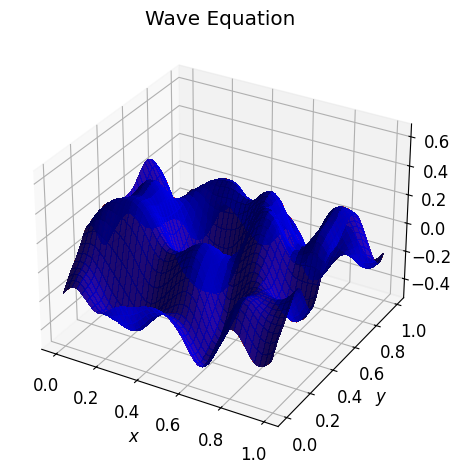

In [33]:
# %matplotlib notebook
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

plt.ion()

fig.show()
fig.canvas.draw()


# x = torch.linspace(0, 1, Nx + 1)[:-1]
# y = torch.linspace(0, 1, Nx + 1)[:-1]
# X, Y = torch.meshgrid(x, y, indexing='ij')
# u = U[key].cpu().numpy()
# u0
surf1 = ax.plot_surface(X, Y, true[..., 0], color='b', label='true', alpha=0.2, linewidth=0, antialiased=False)
surf2 = ax.plot_surface(X, Y, pred[..., 0], color='r', label='pred', alpha=0.2, linewidth=0, antialiased=False)

# pcm = ax.pcolormesh(X, Y, u[0], vmin=-0.5, vmax=0.5, cmap='jet', shading='gouraud')
# divider = make_axes_locatable(ax)
# cax = divider.append_axes("right", size="5%", pad=0.05)

# plt.colorbar(surf, ax=ax)
# fig.colorbar(surf, shrink=0.5, aspect=5)

# ax.
# ax.set_zlim(-1, 1)
# display(ax.get_zlim())
zlim = ax.get_zlim()
ax.set_zlim(zlim)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(f'Wave Equation')
# plt.axis('square')
plt.tight_layout()

# movie_dir = "Wave2D_movie"
# movie_filename = "Wave2D_movie"
# movie_files = []
# os.makedirs(movie_dir, exist_ok=True)
for i in range(len(u)):
    ax.clear()
#     pcm = ax.pcolormesh(X, Y, u[i], vmin=-0.5, vmax=0.5, cmap='jet', shading='gouraud')
    surf1 = ax.plot_surface(X, Y, true[..., i], color='b', label='true', alpha=0.8, linewidth=0, antialiased=False)
    surf2 = ax.plot_surface(X, Y, pred[..., i], color='r', label='pred', alpha=0.8, linewidth=0, antialiased=False)
    ax.set_zlim(zlim)
#     plt.colorbar(pcm, ax=ax)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
#     ax.set_zlabel('$u$')
    plt.title(f'Wave Equation')
#     plt.axis('square')
    plt.tight_layout()
    fig.canvas.draw()
#     movie_path = os.path.join(movie_dir,f'{movie_filename}-{i:03}.png')
#     movie_files.append(movie_path)
#     plt.savefig(movie_path)



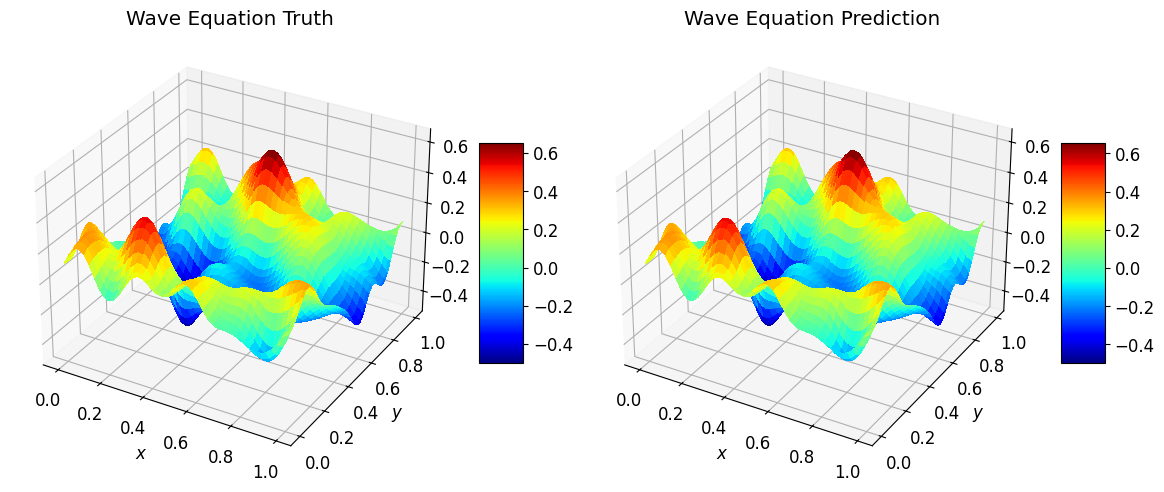

In [34]:
# %matplotlib notebook
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5), subplot_kw={"projection": "3d"})

plt.ion()

fig.show()
fig.canvas.draw()


x = torch.linspace(0, 1, Nx + 1)[:-1]
y = torch.linspace(0, 1, Nx + 1)[:-1]
X, Y = torch.meshgrid(x, y, indexing='ij')
# u = U[key].cpu().numpy()
# u0
# surf1 = ax1.plot_surface(X, Y, true[..., 0], cmap='jet', label='true', alpha=1.0, rstride=1, cstride=1, linewidth=0.0, antialiased=False)
surf1 = ax1.plot_surface(X, Y, true[..., 0], cmap='jet', label='true', linewidth=0.0, antialiased=False)

# plt.colorbar()
# surf2 = ax2.plot_surface(X, Y, pred[..., 0], cmap='jet', label='pred', alpha=1.0, rstride=1, cstride=1, linewidth=0.0, antialiased=False)
surf2 = ax2.plot_surface(X, Y, pred[..., 0], cmap='jet', label='pred',linewidth=0.0, antialiased=False)

# pcm = ax.pcolormesh(X, Y, u[0], vmin=-0.5, vmax=0.5, cmap='jet', shading='gouraud')
# divider = make_axes_locatable(ax2)
# cax = divider.append_axes("right", size="5%", pad=0.05)


# fig.colorbar(surf, shrink=0.5, aspect=5)

# ax.
# ax.set_zlim(-1, 1)
# display(ax.get_zlim())
zlim = ax1.get_zlim()
ax1.set_zlim(zlim)
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')
ax2.set_zlim(zlim)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$y$')
ax1.set_title(f'Wave Equation Truth')
ax2.set_title(f'Wave Equation Prediction')
# plt.axis('square')

plt.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)
plt.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)
plt.tight_layout()
# ax2.tight_layout()

# movie_dir = "Wave2D_movie"
# movie_filename = "Wave2D_movie"
# movie_files = []
# os.makedirs(movie_dir, exist_ok=True)
for i in range(pred.shape[-1]):
    ax1.clear()
    ax2.clear()
#     pcm = ax.pcolormesh(X, Y, u[i], vmin=-0.5, vmax=0.5, cmap='jet', shading='gouraud')
#     surf1 = ax1.plot_surface(X, Y, true[..., i], cmap='jet', label='true', alpha=1.0, rstride=1, cstride=1, linewidth=0.0, antialiased=False)
    surf1 = ax1.plot_surface(X, Y, true[..., i], cmap='jet', label='true', linewidth=0.0, antialiased=False)
#     surf2 = ax2.plot_surface(X, Y, pred[..., i], cmap='jet', label='pred', alpha=1.0, rstride=1, cstride=1, linewidth=0.0, antialiased=False)
    surf2 = ax2.plot_surface(X, Y, pred[..., i], cmap='jet', label='pred',linewidth=0.0, antialiased=False)

    ax1.set_zlim(zlim)
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$y$')
    ax2.set_zlim(zlim)
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$y$')
    ax1.set_title(f'Wave Equation Truth')
    ax2.set_title(f'Wave Equation Prediction')
#     plt.title(f'Wave Equation')
#     plt.axis('square')
    plt.tight_layout()
    fig.canvas.draw()
#     movie_path = os.path.join(movie_dir,f'{movie_filename}-{i:03}.png')
#     movie_files.append(movie_path)
#     plt.savefig(movie_path)



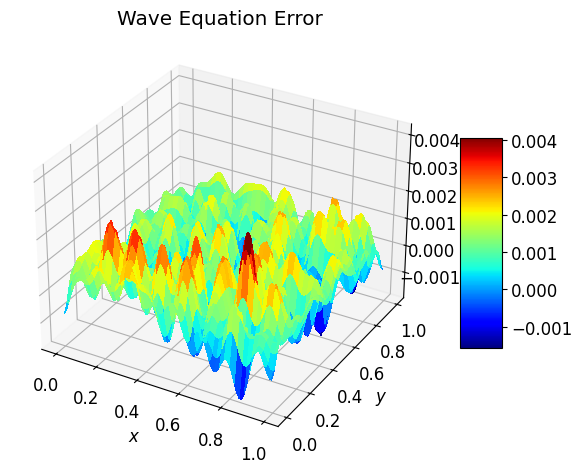

In [35]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

plt.ion()

fig.show()
fig.canvas.draw()


x = torch.linspace(0, 1, Nx + 1)[:-1]
y = torch.linspace(0, 1, Nx + 1)[:-1]
X, Y = torch.meshgrid(x, y, indexing='ij')
surf = ax.plot_surface(X, Y, pred[..., 0] - true[..., 0], cmap='jet', linewidth=0, antialiased=False)
# pcm = ax.pcolormesh(X, Y, u[0], vmin=-0.5, vmax=0.5, cmap='jet', shading='gouraud')
# divider = make_axes_locatable(ax)
# cax = divider.append_axes("right", size="5%", pad=0.05)

# plt.colorbar(surf, ax=ax)
fig.colorbar(surf, shrink=0.5, aspect=5)

# ax.
# ax.set_zlim(-1, 1)
# display(ax.get_zlim())
zlim = ax.get_zlim()
ax.set_zlim(zlim)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(f'Wave Equation Error')
# plt.axis('square')
plt.tight_layout()

# movie_dir = "Wave2D_movie"
# movie_filename = "Wave2D_movie"
# movie_files = []
# os.makedirs(movie_dir, exist_ok=True)
for i in range(len(u)):
    ax.clear()
#     pcm = ax.pcolormesh(X, Y, u[i], vmin=-0.5, vmax=0.5, cmap='jet', shading='gouraud')
    surf = ax.plot_surface(X, Y, pred[..., i] - true[..., i], cmap='jet', linewidth=0, antialiased=False)
    ax.set_zlim(zlim)
#     plt.colorbar(pcm, ax=ax)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
#     ax.set_zlabel('$u$')
    plt.title(f'Wave Equation Error')
#     plt.axis('square')
    plt.tight_layout()
    fig.canvas.draw()
#     movie_path = os.path.join(movie_dir,f'{movie_filename}-{i:03}.png')
#     movie_files.append(movie_path)
#     plt.savefig(movie_path)



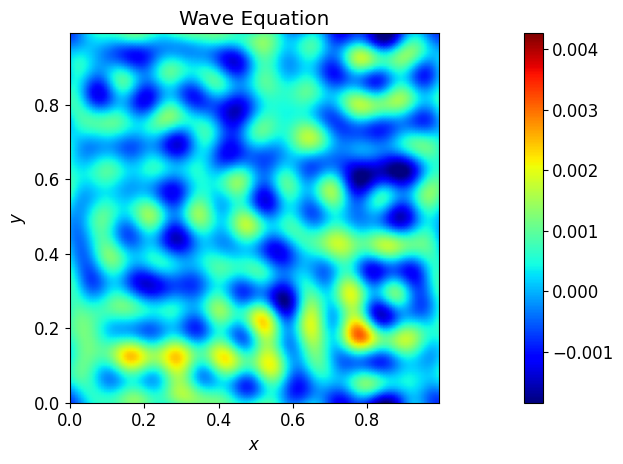

In [36]:
# %matplotlib notebook
fig = plt.figure()
ax = fig.add_subplot(111)
plt.ion()

fig.show()
fig.canvas.draw()


# x = torch.linspace(0, 1, Nx + 1)[:-1]
# y = torch.linspace(0, 1, Nx + 1)[:-1]
# X, Y = torch.meshgrid(x, y, indexing='ij')
# # u = U[key].cpu().numpy()
# u0

pcm = ax.pcolormesh(X, Y, pred[..., 0] - true[..., 0], cmap='jet', shading='gouraud')
# divider = make_axes_locatable(ax)
# cax = divider.append_axes("right", size="5%", pad=0.05)

plt.colorbar(pcm, ax=ax)
# ax.
clim = pcm.get_clim()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(f'Wave Equation')
plt.axis('square')
plt.tight_layout()

# movie_dir = "Wave2D_movie"
# movie_filename = "Wave2D_movie"
# movie_files = []
# os.makedirs(movie_dir, exist_ok=True)
for i in range(len(u)):
    ax.clear()
    pcm = ax.pcolormesh(X, Y, pred[..., i] - true[..., i], cmap='jet', shading='gouraud')
#     plt.colorbar(pcm, ax=ax)
    pcm.set_clim(clim)
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.title(f'Wave Equation')
    plt.axis('square')
    plt.tight_layout()
    fig.canvas.draw()
#     movie_path = os.path.join(movie_dir,f'{movie_filename}-{i:03}.png')
#     movie_files.append(movie_path)
#     plt.savefig(movie_path)

In [37]:
preds_y.shape

(5, 128, 128, 101)

# Save and Load Data

In [38]:
def save_data(data_path, test_x, test_y, preds_y, key_t):
    data_dir, data_filename = os.path.split(data_path)
    os.makedirs(data_dir, exist_ok=True)
    np.savez(data_path, test_x=test_x, test_y=test_y, preds_y=preds_y, key_t=key_t)

def load_data(data_path):
    data = np.load(data_path)
    test_x = data['test_x']
    test_y = data['test_y']
    preds_y = data['preds_y']
    key_t = int(data['key_t'])
    return test_x, test_y, preds_y, key_t

In [39]:
data_dir = 'data/Wave2D'
data_filename = 'data.npz'
data_path = os.path.join(data_dir, data_filename)
# os.makedirs(data_dir, exist_ok=True)


In [40]:
save_data(data_path, test_x, test_y, preds_y, key_t)

In [41]:
test_x, test_y, preds_y, key_t = load_data(data_path)

In [42]:
def plot_predictions(key, key_t, test_x, test_y, preds_y, print_index=False, save_path=None, font_size=None):
    
    if font_size is not None:
        plt.rcParams.update({'font.size': font_size})
        
    pred = preds_y[key]
    true = test_y[key]
    
    Nx, Ny, Nt = pred.shape


    a = test_x[key]
    # Nt, Nx, _ = a.shape
    u0 = a[..., 0, -1]
    pred_t = pred[..., key_t]
    true_t = true[..., key_t]
    # T = a[:,:,2]
    # X = a[:,:,1]
    # x = X[0]
    x = torch.linspace(0, 1, Nx + 1)[:-1]
    y = torch.linspace(0, 1, Ny + 1)[:-1]
    X, Y = torch.meshgrid(x, y, indexing='ij')
    t = a[0, 0, key_t, 2]

    # Plot
    fig = plt.figure(figsize=(24,5))
    plt.subplot(1,4,1)

    plt.pcolormesh(X, Y, u0, cmap='jet', shading='gouraud')
    plt.colorbar()
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.title('Intial Condition $u(x,y)$')
    plt.tight_layout()
    plt.axis('square')

    plt.subplot(1,4,2)
    # plt.pcolor(XX,TT, S_test, cmap='jet')
    plt.pcolormesh(X, Y, true_t, cmap='jet', shading='gouraud')
    plt.colorbar()
    plt.xlabel('$x$')
    plt.ylabel('$y$')
#     plt.title(f'Exact $u(x,y,t={t:.2f})$')
    plt.title(f'Exact $u(x,y,t={int(t)})$')
    plt.tight_layout()
    plt.axis('square')

    plt.subplot(1,4,3)
    # plt.pcolor(XX,TT, S_pred, cmap='jet')
    plt.pcolormesh(X, Y, pred_t, cmap='jet', shading='gouraud')
    plt.colorbar()
    plt.xlabel('$x$')
    plt.ylabel('$y$')
#     plt.title(f'Predict $u(x,y,t={t:.2f})$')
    plt.title(f'Predict $u(x,y,t={int(t)}$')

    plt.axis('square')

    plt.tight_layout()

    plt.subplot(1,4,4)
    # plt.pcolor(XX,TT, S_pred - S_test, cmap='jet')
    plt.pcolormesh(X, Y, pred_t - true_t, cmap='jet', shading='gouraud')
    plt.colorbar()
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.title('Absolute Error')
    plt.tight_layout()
    plt.axis('square')

    if save_path is not None:
        plt.savefig(f'{save_path}.png', bbox_inches='tight')
    plt.show()

    


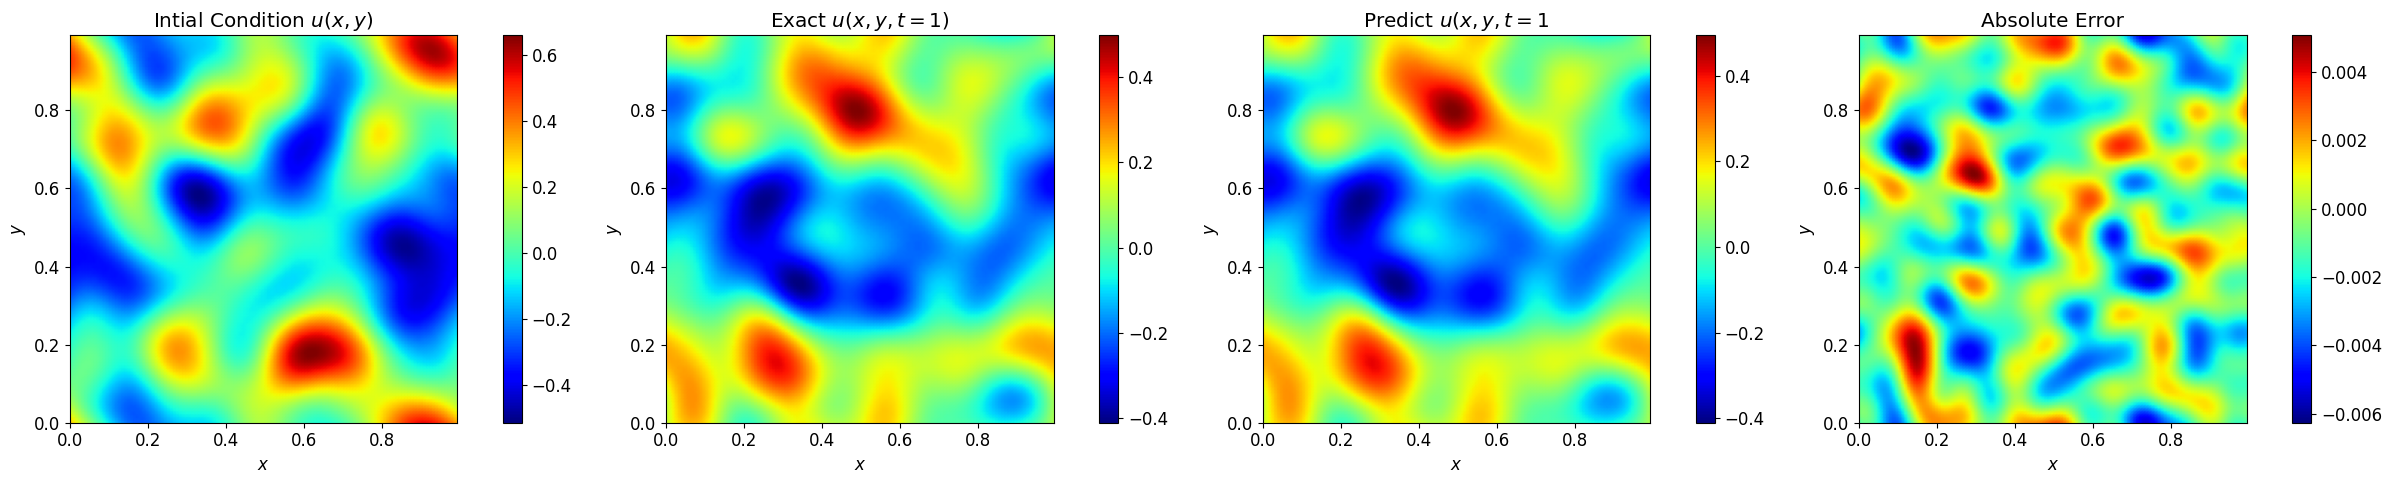

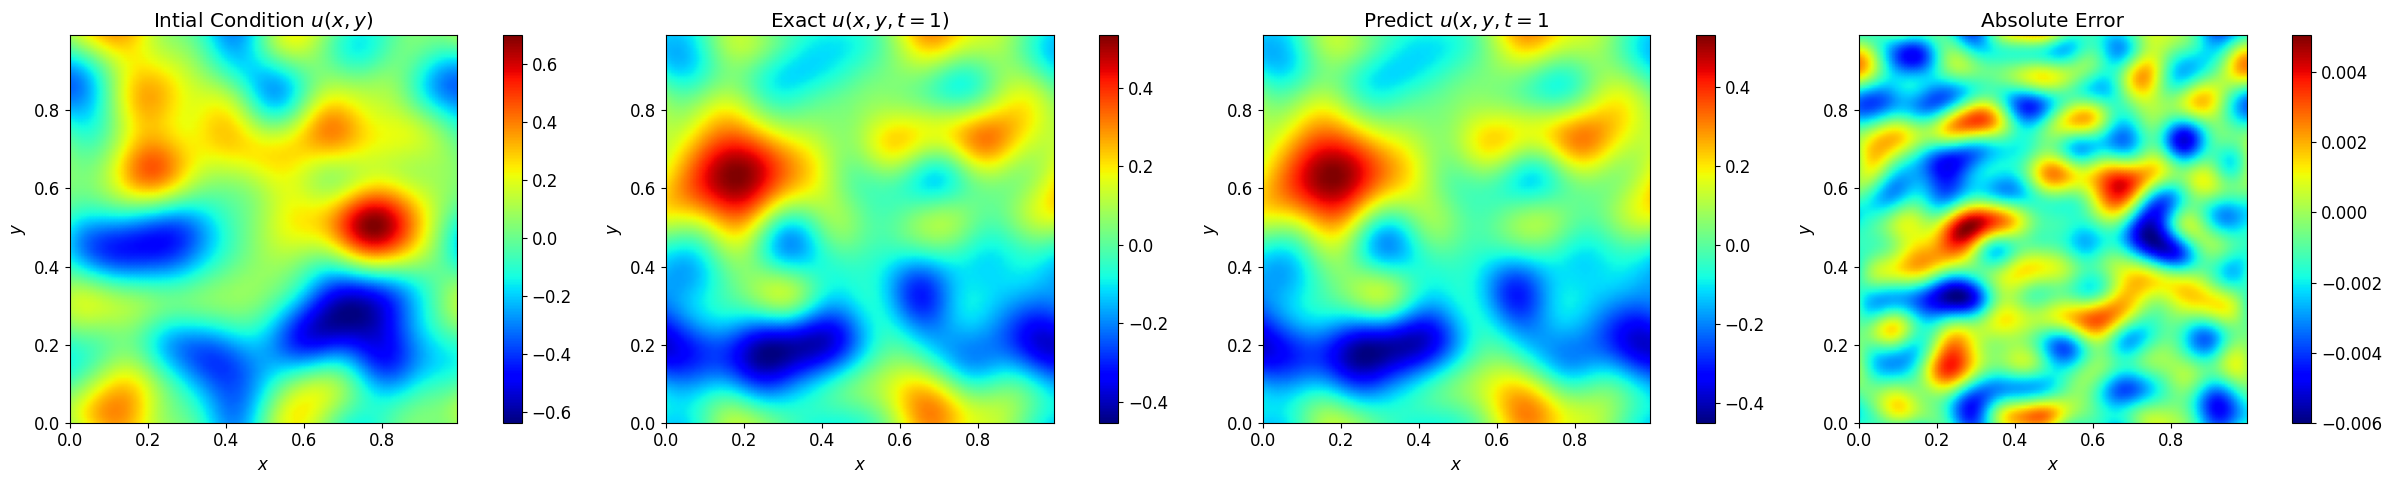

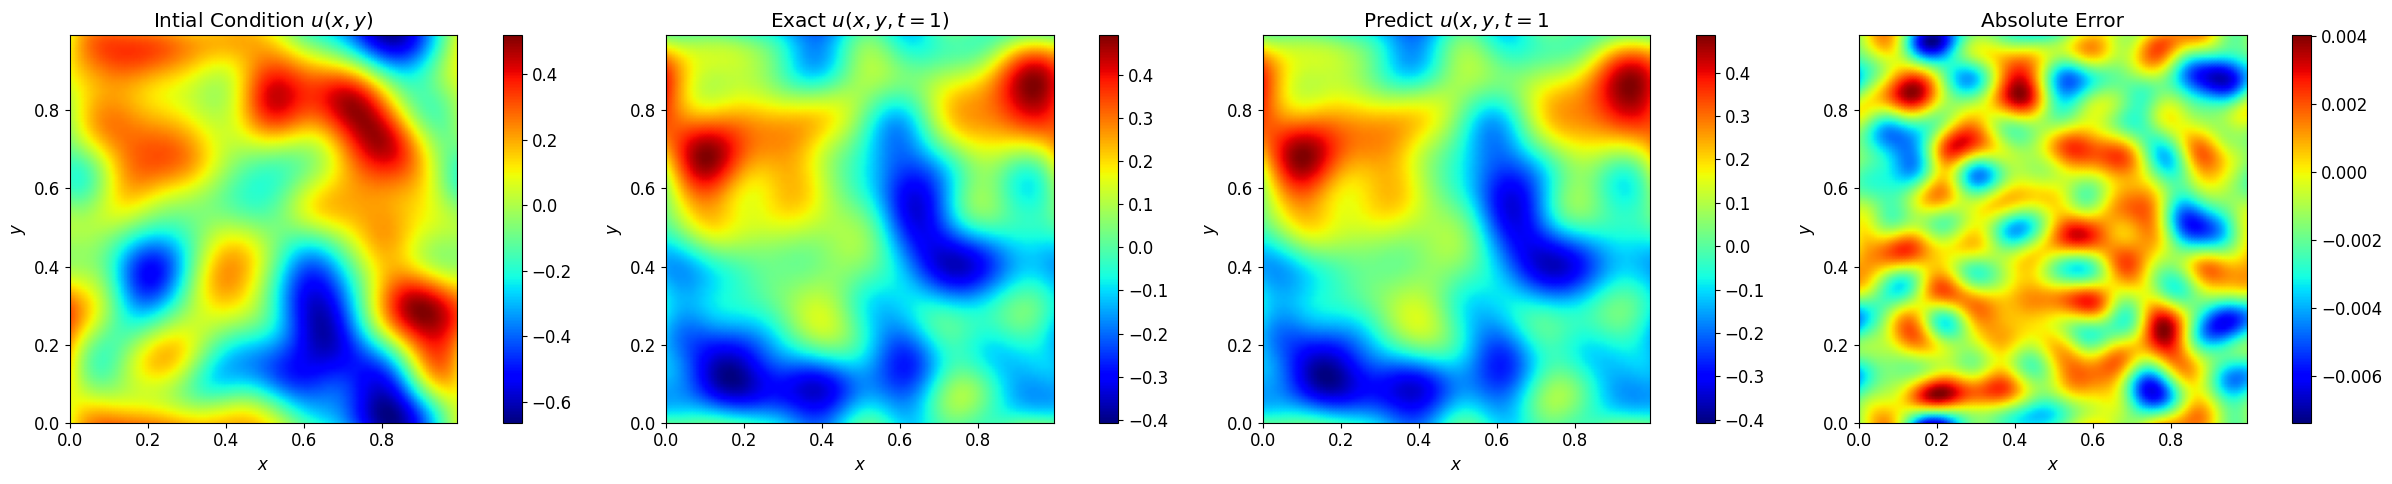

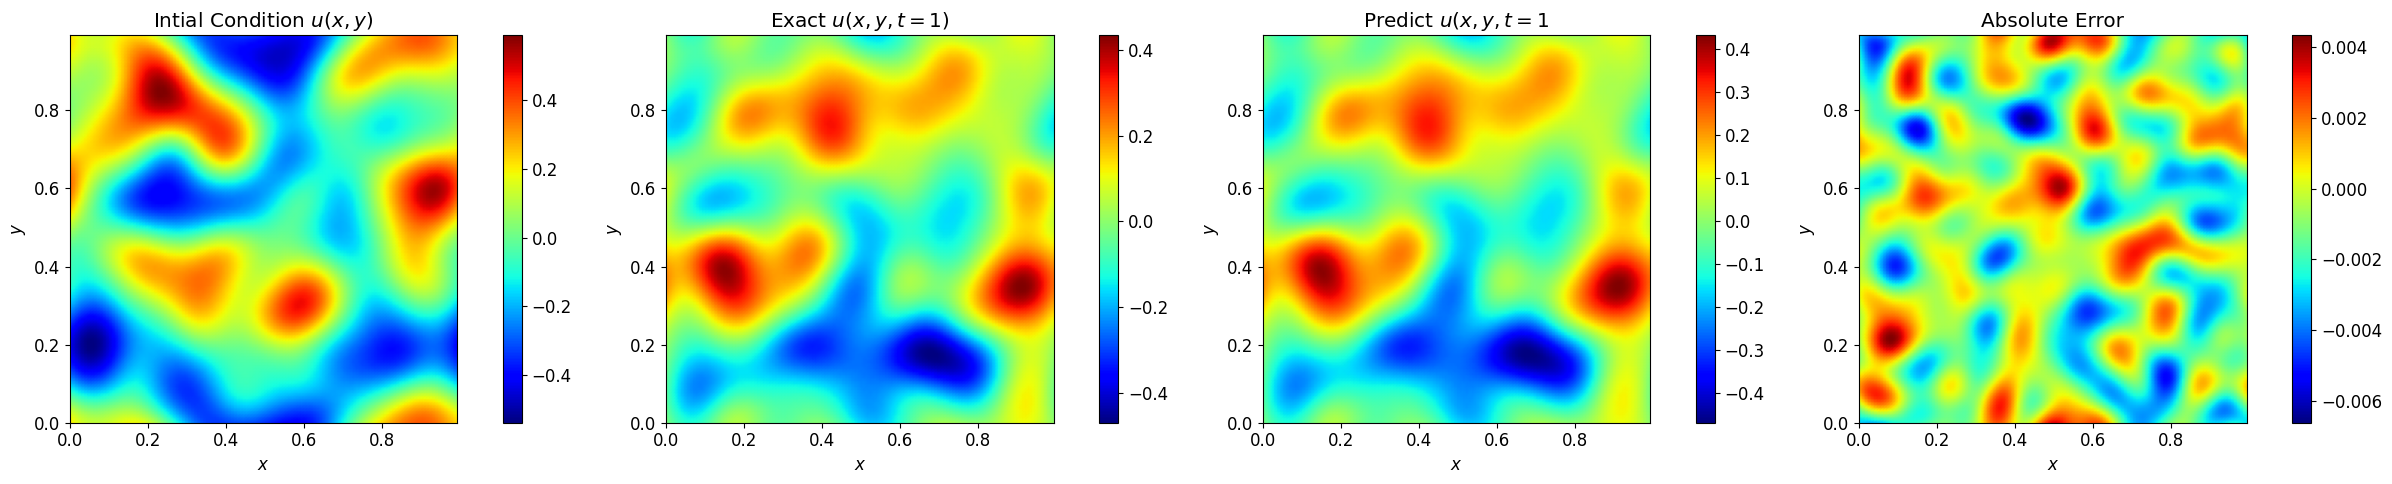

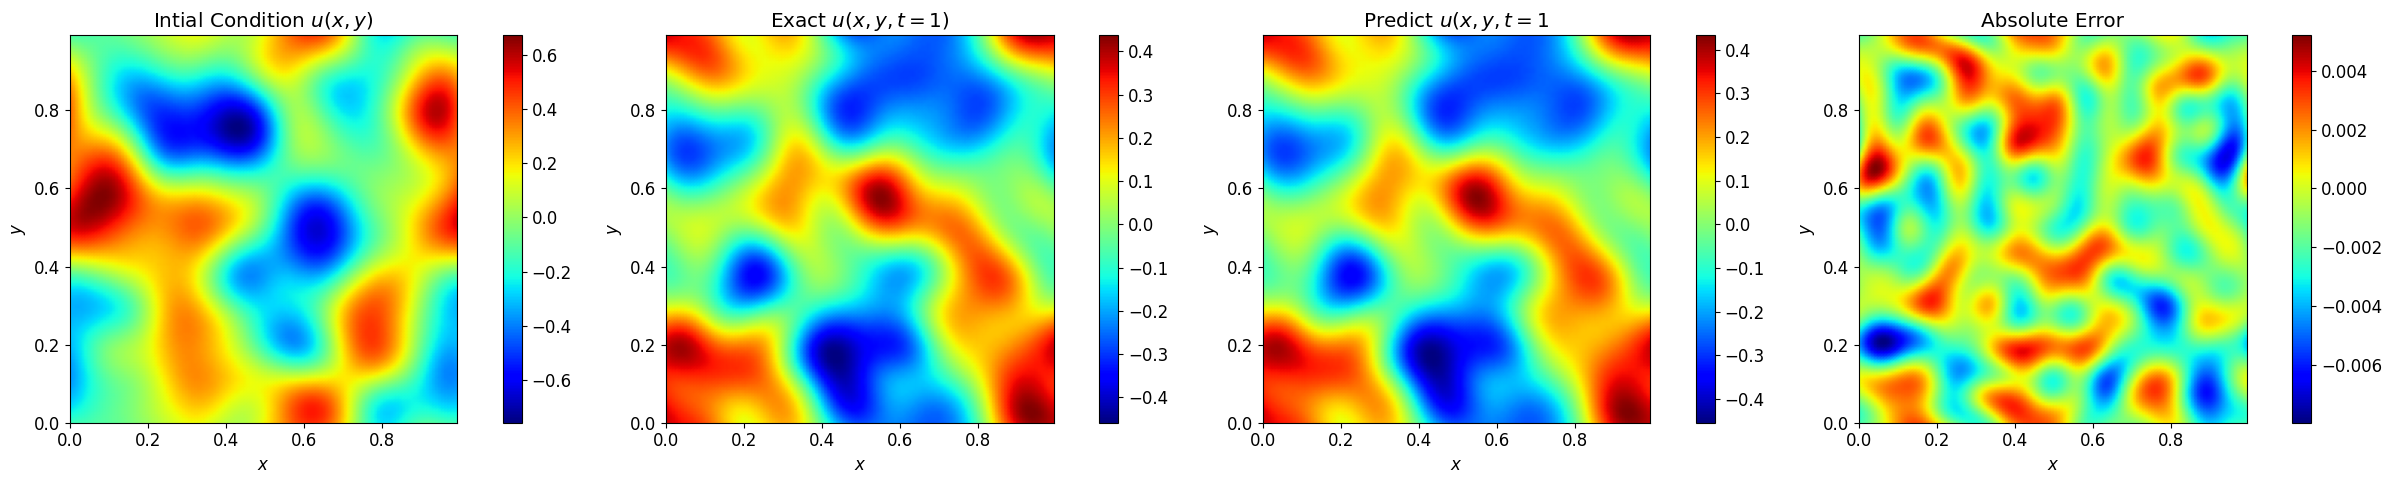

In [43]:
figures_dir = 'Wave2D/figures/'
os.makedirs(figures_dir, exist_ok=True)
font_size = 12
for key in range(len(preds_y)):
    save_path = os.path.join(figures_dir, f'Wave{key}')
#     plot_predictions(key, key_t, test_x, test_y, preds_y, print_index=True, save_path=None)
    plot_predictions(key, key_t, test_x, test_y, preds_y, print_index=True, save_path=save_path, font_size=font_size)


## Movies

In [45]:
def generate_movie_2D(key, test_x, test_y, preds_y, plot_title='', field=0, val_cbar_index=-1, err_cbar_index=-1, val_clim=None, err_clim=None, font_size=None, movie_dir='', movie_name='movie.gif', frame_basename='movie', frame_ext='jpg', remove_frames=True):
    frame_files = []
    
    if movie_dir:
        os.makedirs(movie_dir, exist_ok=True)
    
    if font_size is not None:
        plt.rcParams.update({'font.size': font_size})
    
    if len(preds_y.shape) == 4:
        Nsamples, Nx, Ny, Nt = preds_y.shape
        preds_y = preds_y.reshape(Nsamples,Nx,Ny,Nt,1)
        test_y = test_y.reshape(Nsamples,Nx,Ny,Nt,1)
    Nsamples, Nx, Ny, Nt, Nfields = preds_y.shape    
    
    pred = preds_y[key, ..., field]
    true = test_y[key, ..., field]
    error = pred - true
    

    a = test_x[key]
    x = torch.linspace(0, 1, Nx + 1)[:-1]
    y = torch.linspace(0, 1, Ny + 1)[:-1]
    X, Y = torch.meshgrid(x, y, indexing='ij')
    t = a[0, 0, :, 2]
    
    
    fig, axs = plt.subplots(1, 3, figsize=(18,5))
    ax1 = axs[0]
    ax2 = axs[1]
    ax3 = axs[2]
    
    pcm1 = ax1.pcolormesh(X, Y, true[..., val_cbar_index], cmap='jet', label='true', shading='gouraud')
    pcm2 = ax2.pcolormesh(X, Y, pred[..., val_cbar_index], cmap='jet', label='pred', shading='gouraud')
    pcm3 = ax3.pcolormesh(X, Y, error[..., err_cbar_index], cmap='jet', label='error', shading='gouraud')
    
    if val_clim is None:
        val_clim = pcm1.get_clim()
    if err_clim is None:
        err_clim = pcm3.get_clim()
        
    
    
    pcm1.set_clim(val_clim)
    plt.colorbar(pcm1, ax=ax1)
    ax1.axis('square')
    
    
    pcm2.set_clim(val_clim)
    plt.colorbar(pcm2, ax=ax2)
    ax2.axis('square')
    
    pcm3.set_clim(err_clim)
    plt.colorbar(pcm3, ax=ax3)
    ax3.axis('square')

    plt.tight_layout()
    
    for i in range(Nt):
        # Exact
        ax1.clear()
        pcm1 = ax1.pcolormesh(X, Y, true[..., i], cmap='jet', label='true', shading='gouraud')
        pcm1.set_clim(val_clim)
        ax1.set_title(f'Exact {plot_title}: $t={t[i]:.2f}$')
        ax1.axis('square')

        # Predictions
        ax2.clear()
        pcm2 = ax2.pcolormesh(X, Y, pred[..., i], cmap='jet', label='pred', shading='gouraud')
        pcm2.set_clim(val_clim)
        ax2.set_title(f'Predict {plot_title}: $t={t[i]:.2f}$')
        ax2.axis('square')
        
        # Error
        ax3.clear()
        pcm3 = ax3.pcolormesh(X, Y, error[..., i], cmap='jet', label='error', shading='gouraud')
        pcm3.set_clim(err_clim)
        ax3.set_title(f'Error {plot_title}: $t={t[i]:.2f}$')
        ax3.axis('square')
        
#         plt.tight_layout()
        fig.canvas.draw()
        
        if movie_dir:
            frame_path = os.path.join(movie_dir,f'{frame_basename}-{i:03}.{frame_ext}')
            frame_files.append(frame_path)
            plt.savefig(frame_path, bbox_inches='tight')

    

    if movie_dir:
        movie_path = os.path.join(movie_dir, movie_name)
        with imageio.get_writer(movie_path, mode='I') as writer:
            for frame in frame_files:
                image = imageio.imread(frame)
                writer.append_data(image)
                
    if movie_dir and remove_frames:
        for frame in frame_files:
            try:
                os.remove(frame)
            except:
                pass


### Movie Parameters

In [46]:
movie_dir = 'Wave2D/movie/'
os.makedirs(movie_dir, exist_ok=True)
data_dir = 'data/Wave2D'
data_filename = 'data.npz'
data_path = os.path.join(data_dir, data_filename)
test_x, test_y, preds_y, key_t = load_data(data_path)

### Movie 1 $u$

/tmp/ipykernel_272401/2478022230.py:95: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(frame)


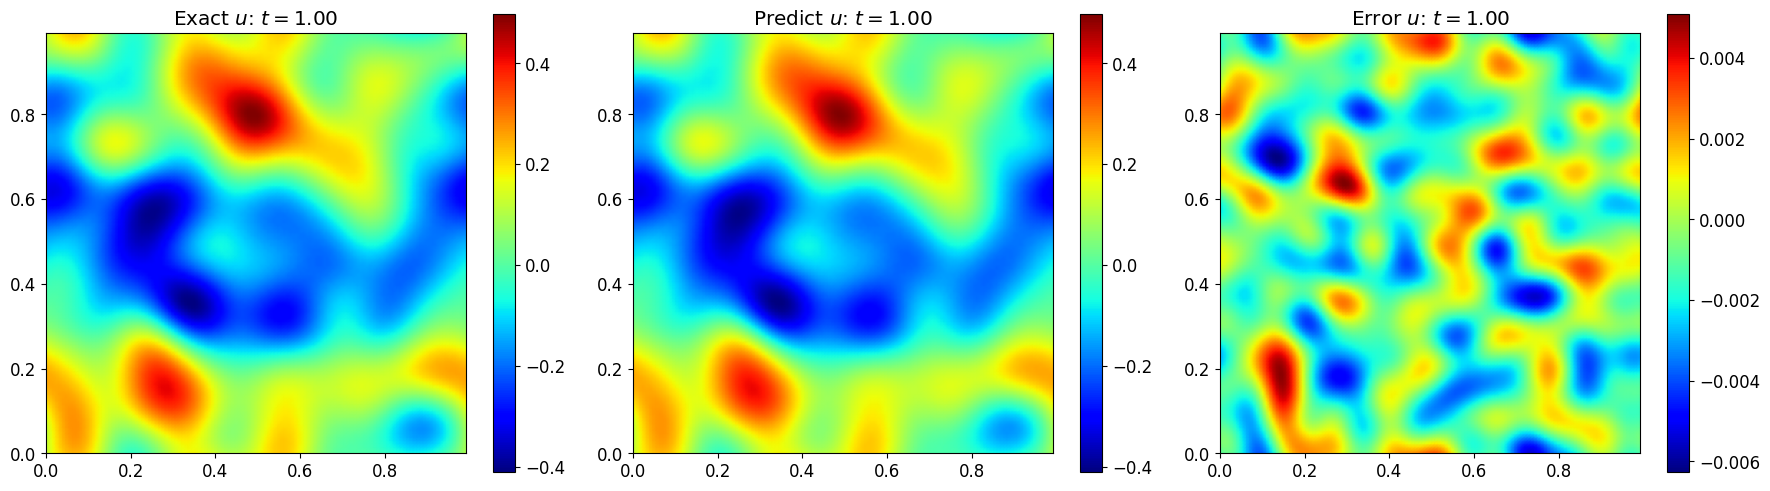

In [47]:
%matplotlib inline
key = 0
movie_name = f'Wave2D_{key}.gif'
frame_basename = f'Wave2D_{key}_frame'
frame_ext = 'jpg'
plot_title = "$u$"
field = 0
val_cbar_index = -1
err_cbar_index = -1
font_size = 12
remove_frames = True

generate_movie_2D(key, test_x, test_y, preds_y, 
                  plot_title=plot_title, 
                  field=field, 
                  val_cbar_index=val_cbar_index, 
                  err_cbar_index=err_cbar_index, 
                  movie_dir=movie_dir, 
                  movie_name=movie_name, 
                  frame_basename=frame_basename, 
                  frame_ext=frame_ext, 
                  remove_frames=remove_frames, 
                  font_size=font_size)


### Movie 2 $u$

/tmp/ipykernel_272401/2478022230.py:95: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(frame)


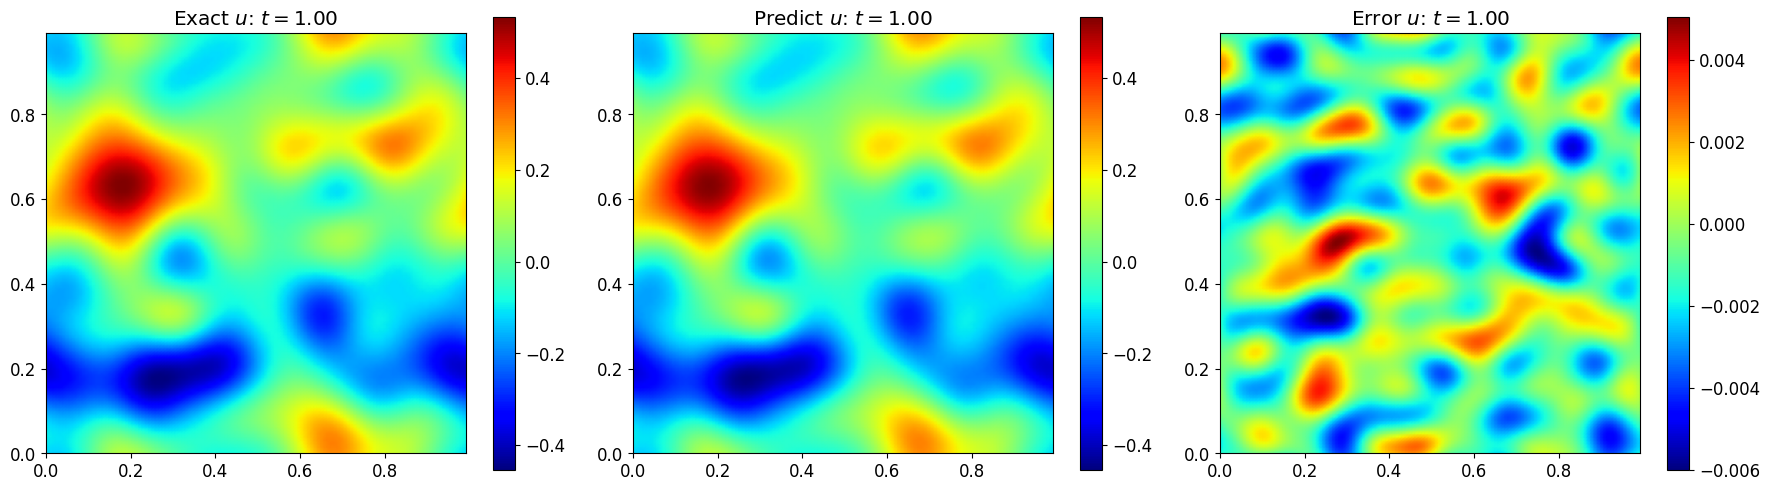

: 

In [ ]:
%matplotlib inline
key = 1
movie_name = f'Wave2D_{key}.gif'
frame_basename = f'Wave2D_{key}_frame'
frame_ext = 'jpg'
plot_title = "$u$"
field = 0
val_cbar_index = -1
err_cbar_index = -1
font_size = 12
remove_frames = True

generate_movie_2D(key, test_x, test_y, preds_y, 
                  plot_title=plot_title, 
                  field=field, 
                  val_cbar_index=val_cbar_index, 
                  err_cbar_index=err_cbar_index, 
                  movie_dir=movie_dir, 
                  movie_name=movie_name, 
                  frame_basename=frame_basename, 
                  frame_ext=frame_ext, 
                  remove_frames=remove_frames, 
                  font_size=font_size)
